## Q11

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import norm

In [4]:
np.random.seed(42)

In [5]:
''' 
    Set Up for Simulation 1 (psi is a particular value)

'''
# Simulation parameters
r = 0
mu = 0
S0 = 100
B0 = 1
sigma = 0.20
theta_0 = 30
b_0 = 0
b = -100
beta = 0.28
alpha = 0.5
phi = 1
gamma = 0.2
zeta = 0.25
w0 = 10

#Time
dt = 8 / (365 * 24 * 1)  # daily
T = 1  # total time in years
N = int(T / dt) 
M = 3  # number of paths
quarter_len = int(0.25 / dt)  # 每季度步数
opex_indices = [0, quarter_len, 2 * quarter_len, 3 * quarter_len, N]

#Parameters to Change
psi = 3





In [6]:
''' 
    Calculation Functions 
'''
    
def bs_put_price(S, K, T, sigma, r=0):
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    except ZeroDivisionError:

        return 0.0
    
def bs_call_price(S, K, T, sigma, r =0):
    try:
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        d2 = d1 - sigma * np.sqrt(T)
        return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    except ZeroDivisionError:
        return 0.0
    
def bs_delta(S, K, T, sigma, option_type='call', r=0):
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    if option_type == 'call':
        return norm.cdf(d1)
    else:
        return norm.cdf(d1) - 1
    
def bs_gamma(S, K, T, sigma, r=0):
    """
    Black–Scholes Gamma: ∂²C/∂S²
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    # gamma formula
    return norm.pdf(d1) / (S * sigma * np.sqrt(T))

def bs_charm(S, K, T, sigma, r=0):
    """
    Black–Scholes Charm: ∂²C/∂t∂S = ∂(Delta)/∂t
    For r=0 simplifies to: -φ(d1)*d2/(2*T)
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1, d2
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    d2 = d1 - sigma * sqrtT
    # charm formula
    return -norm.pdf(d1) * d2 / (2 * T)

def bs_speed(S, K, T, sigma, r=0):
    """
    Black–Scholes Speed: ∂³C/∂S³ = ∂(Gamma)/∂S
    Simplified finite formula:
      ∂Γ/∂S = -d1*φ(d1)/(S² σ² T) - φ(d1)/(S² σ √T)
    """
    if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
        return 0.0
    # compute d1
    sqrtT = np.sqrt(T)
    d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
    pdf_d1 = norm.pdf(d1)
    term1 = -d1 * pdf_d1 / (S**2 * sigma**2 * T)
    term2 = -pdf_d1 / (S**2 * sigma * sqrtT)
    return term1 + term2

In [7]:
def dDeltaCalc(S_t, sigma, K, T):

    def bs_delta(S, K, T, sigma, option_type='call', r=0):
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        if option_type == 'call':
            return norm.cdf(d1)
        else:
            return norm.cdf(d1) - 1
    
    def bs_gamma(S, K, T, sigma, r=0):
        """
        Black–Scholes Gamma: ∂²C/∂S²
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
        # gamma formula
        return norm.pdf(d1) / (S * sigma * np.sqrt(T))

    def bs_charm(S, K, T, sigma, r=0):
        """
        Black–Scholes Charm: ∂²C/∂t∂S = ∂(Delta)/∂t
        For r=0 simplifies to: -φ(d1)*d2/(2*T)
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1, d2
        sqrtT = np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
        d2 = d1 - sigma * sqrtT
        # charm formula
        return -norm.pdf(d1) * d2 / (2 * T)

    def bs_speed(S, K, T, sigma, r=0):
        """
        Black–Scholes Speed: ∂³C/∂S³ = ∂(Gamma)/∂S
        Simplified finite formula:
        ∂Γ/∂S = -d1*φ(d1)/(S² σ² T) - φ(d1)/(S² σ √T)
        """
        if T <= 0 or sigma <= 0 or S <= 0 or K <= 0:
            return 0.0
        # compute d1
        sqrtT = np.sqrt(T)
        d1 = (np.log(S / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * sqrtT)
        pdf_d1 = norm.pdf(d1)
        term1 = -d1 * pdf_d1 / (S**2 * sigma**2 * T)
        term2 = -pdf_d1 / (S**2 * sigma * sqrtT)
        return term1 + term2

    #2nd and 3rd Order Greeks 
    gamma = bs_gamma(S_t, K, T, sigma)
    charm = bs_charm(S_t, K, T, sigma)
    speed = bs_speed(S_t, K, T, sigma)
    
    return gamma, charm, speed

## Working


In [ ]:
#Old Version
def simulate_full_paths(S0, b_0, sigma, psi, zeta, phi, theta_0, b,
                        dt, N, M, opex_indices, asset_type='NVDA'):
    
    ''' 
    N : number of simulations
    M : number of time steps
    theta_0 : Number of Puts and Calls bought (option size)
    '''
    #Stock Price
    S = np.zeros((M, N + 1)) 
    S[:, 0] = S0
    dDelta = np.zeros((M, N)) 
    M_t = np.zeros((M, N)) 
    delta_t = np.zeros((M, N + 1))
    portfolio_value = np.zeros((M, N + 1))

    #Greeks
    charm = np.zeros((M, N))
    speed = np.zeros((M, N))
    gamma_greek = np.zeros((M, N))

    #MMA
    b_t_I = np.zeros((M, N + 1))
    b_t_I[:, 0] = b_0

    #Number of Options

    K_call = np.zeros((M, len(opex_indices)))
    K_put = np.zeros((M, len(opex_indices)))
    exp_phi_dt = np.exp(-phi * dt)  # Precompute exp(-phi * dt) for efficiency

    #Opex Date Logic
    T_remain = 0.25
    sqrt_remain = np.sqrt(T_remain)
    sqrt_dt = np.sqrt(dt)

    for path in range(M):
        for t in range(N + 1):
            if t == 0:
                #Opex idx counter
                idx = 0
                S_t = S0
                #Strike Price
                K_call[path, 0] = S0 * np.exp(sigma * sqrt_remain) 
                K_put[path, 0] = S0 * np.exp(-sigma * sqrt_remain)

                #Black Sholes Price
                put_price = bs_put_price(S=S0, K=K_put[path, 0], T=T_remain, sigma=sigma)
                call_price = bs_call_price(S=S0, K=K_call[path, 0], T=T_remain, sigma=sigma)

                #Stock Process
                delta_call = bs_delta(S0, K_call[path, 0], T_remain, sigma, 'call')
                delta_put = bs_delta(S0, K_put[path, 0], T_remain, sigma, 'put')
            
                theta = (b_0 - theta_0 * S0) / (put_price + call_price)
                theta_t = theta

                prev_delta = theta_0 * (delta_put + delta_call) 

            if t > 0 and t not in opex_indices:
                delta_t[path, t] = prev_delta
                M_prev = M_t[path, t-2] if t > 1 else 0.0
                last_opex_t = max([i for i in opex_indices if i < t])
                tau = T_remain - (t - last_opex_t) * dt
                tau = max(tau, 1e-6) 
                # Calculate the feedback and diffusion terms

                # 1. Calculate dDelta
                Call_Gamma, Call_Charm, Call_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_call[path, idx],
                                         T = tau)
                # For Put
                Put_Gamma, Put_Charm, Put_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_put[path, idx],
                                         T = tau)
                # Calculate net Greeks
                net_gamma =  (Call_Gamma + Put_Gamma) 
                net_charm =  (Call_Charm + Put_Charm) 
                net_speed =  (Call_Speed + Put_Speed) 
                charm[path, t-1] = net_charm
                gamma_greek[path, t-1] = net_gamma
                speed[path, t-1] = net_speed
                #Calculate dDelta_dealer

                dW = np.random.normal(0, sqrt_dt)
                dt_terms = net_charm + (net_gamma * M_prev * S_t * psi) + 0.5*(net_speed*sigma**2 *S_t**(2-2*zeta))
                dW_terms = dW * sigma * S_t**(1-zeta) * net_gamma
                dDelta_Current = dt_terms*dt + dW_terms 

                dDelta[path, t-1] = dDelta_Current

                # 2. Calculate M_t
                M_t[path, t-1] = exp_phi_dt * M_prev + dDelta_Current
               
                # 3. Calculate Diffusion 
                diffusion = sigma * S_t **(1 - zeta) * dW
                # 4. Calculate Drift
                drift = psi * S_t * M_prev * dt
                # 4. Update New S_t
                
                S[path, t] =  diffusion + drift + S_t
                S_t = S[path, t]

               

            if t in opex_indices and t != 0:
                #Initial Opex Logic
                M_t[path, t-1] = 0
                idx = opex_indices.index(t)

                #New Option's Strike Price for the upcoming Period
                K_call[path, idx] = S_t * np.exp(sigma * sqrt_remain) + 0.25 * (diffusion / dW)
                K_put[path, idx] = S_t * np.exp(-sigma * sqrt_remain) - 0.25 * (diffusion / dW)
                #New Options Prices
                call_price = bs_call_price(S=S_t, K=K_call[path, idx], T=T_remain, sigma=sigma)
                put_price = bs_put_price(S=S_t, K=K_put[path, idx], T=T_remain, sigma=sigma)
                unit_cost = call_price + put_price
     
                
                #Calculate Payoff from Matured Option
                call_payoff = theta_t * max(S_t - K_call[path, idx - 1], 0)
                put_payoff = theta_t * max(K_put[path, idx - 1] - S_t, 0)

                #Update Money in MMA
                b_t = b_t_I[path, t - 1] + (call_payoff + put_payoff) * theta_t 
            
                #If we are within our borrowing limits
                avaliable_money = b_t - b
                if avaliable_money >= theta_0 * (put_price + call_price):
                    theta_new = theta_0 
                else:
                    theta_new = (b_t - b) / (put_price + call_price)
                    print('outside')

                #New Money in MMA
                b_t_I[path, t] = b_t - theta_new * unit_cost                
                #New Delta Calculations
                delta_call_new = bs_delta(S_t, K_call[path, idx], T_remain, sigma, 'call')
                delta_put_new = bs_delta(S_t, K_put[path, idx], T_remain, sigma, 'put')
                #Delta Jump
                new_delta = theta_new * (delta_put_new + delta_call_new)
                dDelta[path, t - 1] = new_delta - prev_delta
                #Update Deltas
                delta_t[path, t] = new_delta
                prev_delta = new_delta
                theta_t = theta_new
                S[path, t] = S_t
            #If we are not at an Opex date

            elif t > 0:
                b_t_I[path, t] = b_t_I[path, t - 1]
        
        portfolio_value[path, t] = prev_delta * S_t + b_t_I[path, t]

    return {
        'S': pd.DataFrame(S),
        'b': pd.DataFrame(b_t_I),
        'M': pd.DataFrame(M_t),
        'dDelta': pd.DataFrame(dDelta),
        'delta': pd.DataFrame(delta_t),
        'gamma': pd.DataFrame(gamma_greek),
        'speed': pd.DataFrame(speed),
        'charm' : pd.DataFrame(charm),
        'portfolio': pd.DataFrame(portfolio_value)
    }

In [33]:
def simulate_full_paths(S0, b_0, sigma, psi, zeta, phi, theta_0, b,
                        dt, N, M, opex_indices, asset_type='NVDA'):

    '''
    N : number of simulations
    M : number of time steps
    theta_0 : Number of Puts and Calls bought (option size)
    '''
    #Stock Price
    S = np.zeros((M, N + 1))
    S[:, 0] = S0
    dDelta = np.zeros((M, N))
    M_t = np.zeros((M, N))
    delta_t = np.zeros((M, N + 1))


    #Greeks
    charm = np.zeros((M, N))
    speed = np.zeros((M, N))
    gamma_greek = np.zeros((M, N))

    #MMA



    #Number of Options

    K_call = np.zeros((M, len(opex_indices)))
    K_put = np.zeros((M, len(opex_indices)))
    b_t_I = np.zeros((M, len(opex_indices)+1))
    b_t_I[:, 0] = b_0
    portfolio_value = np.zeros((M, N))
    portfolio_value[:, 0] = abs(b)
    exp_phi_dt = np.exp(-phi * dt)  # Precompute exp(-phi * dt) for efficiency

    #Opex Date Logic
    T_remain = 0.25
    sqrt_remain = np.sqrt(T_remain)
    sqrt_dt = np.sqrt(dt)

    for path in range(M):
        for t in range(N + 1):
            if t == 0:
                #Opex idx counter
                idx = 0
                S_t = S0
                #Strike Price
                K_call[path, 0] = S0 * np.exp(sigma * sqrt_remain)
                K_put[path, 0] = S0 * np.exp(-sigma * sqrt_remain)

                #Black Sholes Price
                put_price = bs_put_price(S=S0, K=K_put[path, 0], T=T_remain, sigma=sigma)
                call_price = bs_call_price(S=S0, K=K_call[path, 0], T=T_remain, sigma=sigma)

                #Stock Process
                delta_call = bs_delta(S0, K_call[path, 0], T_remain, sigma, 'call')
                delta_put = bs_delta(S0, K_put[path, 0], T_remain, sigma, 'put')

                theta_t = theta_0

                b_t_I[path, 1] = b_0 - theta_0*(put_price + call_price)
                dDelta[path,0]= (delta_put + delta_call)*theta_0

                prev_delta = theta_0 * (1+delta_put + delta_call)
                portfolio_value [path, 0] = S0*theta_0

            if t > 0 and t not in opex_indices:
                delta_t[path, t] = prev_delta
                M_prev = M_t[path, t-2] if t > 1 else 0.0
                last_opex_t = max([i for i in opex_indices if i < t])
                tau = T_remain - (t - last_opex_t) * dt
                tau = max(tau, 1e-6)
                # Calculate the feedback and diffusion terms

                # 1. Calculate dDelta
                Call_Gamma, Call_Charm, Call_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_call[path, idx],
                                         T = tau)
                # For Put
                Put_Gamma, Put_Charm, Put_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_put[path, idx],
                                         T = tau)
                # Calculate net Greeks
                net_gamma =  (Call_Gamma + Put_Gamma)
                net_charm =  (Call_Charm + Put_Charm)
                net_speed =  (Call_Speed + Put_Speed)
                charm[path, t-1] = net_charm
                gamma_greek[path, t-1] = net_gamma
                speed[path, t-1] = net_speed
                #Calculate dDelta_dealer

                dW = np.random.normal(0, sqrt_dt)
                dt_terms = net_charm + (net_gamma * M_prev * S_t * psi) + 0.5*(net_speed*sigma**2 *S_t**(2-2*zeta))
                dW_terms = dW * sigma * S_t**(1-zeta) * net_gamma
                dDelta_Current = dt_terms*dt + dW_terms

                dDelta[path, t-1] = dDelta_Current

                # 2. Calculate M_t
                M_t[path, t-1] = exp_phi_dt * M_prev + dDelta_Current

                # 3. Calculate Diffusion
                diffusion = sigma * S_t **(1 - zeta) * dW
                # 4. Calculate Drift
                drift = psi * S_t * M_prev * dt
                # 4. Update New S_t

                S[path, t] =  diffusion + drift + S_t
                S_t = S[path, t]



            if t in opex_indices and t != 0:
                #Initial Opex Logic
                M_t[path, t-1] = 0
                idx = opex_indices.index(t)

                #New Option's Strike Price for the upcoming Period
                K_call[path, idx] = S_t * np.exp(sigma * sqrt_remain) + 0.25 * (diffusion / dW)
                K_put[path, idx] = S_t * np.exp(-sigma * sqrt_remain) - 0.25 * (diffusion / dW)
                #New Options Prices
                call_price = bs_call_price(S=S_t, K=K_call[path, idx], T=T_remain, sigma=sigma)
                put_price = bs_put_price(S=S_t, K=K_put[path, idx], T=T_remain, sigma=sigma)
                unit_cost = call_price + put_price


                #Calculate Payoff from Matured Option
                call_payoff = theta_t * max(S_t - K_call[path, idx - 1], 0)
                put_payoff = theta_t * max(K_put[path, idx - 1] - S_t, 0)


                #Update Money in MMA
                b_t = b_t_I[path, idx] + (call_payoff + put_payoff) * theta_t


                #If we are within our borrowing limits
                avaliable_money = b_t - b
                if avaliable_money >= theta_0 * (put_price + call_price):
                    theta_new = theta_0
                else:
                    theta_new = (b_t - b) / (put_price + call_price)

                #New Money in MMA
                b_t_I[path, idx+1] = b_t - theta_new * unit_cost
                #New Delta Calculations
                delta_call_new = bs_delta(S_t, K_call[path, idx], T_remain, sigma, 'call')
                delta_put_new = bs_delta(S_t, K_put[path, idx], T_remain, sigma, 'put')
                #Delta Jump [‼️i add 1 because we need to include the delta for the underlying]
                new_delta = theta_0*1 + theta_new * (delta_put_new + delta_call_new)
                dDelta[path, t - 1] = new_delta - prev_delta
                #Update Deltas
                delta_t[path, t] = new_delta
                prev_delta = new_delta
                #Portfolio value
                portfolio_value[path, idx] = theta_t * (unit_cost) + b_t_I[path, idx+1] + theta_0*S_t
                theta_t = theta_new
                S[path, t] = S_t
            #If we are not at an Opex date






    return {
        'S': pd.DataFrame(S),
        'b': pd.DataFrame(b_t_I),
        'M': pd.DataFrame(M_t),
        'dDelta': pd.DataFrame(dDelta),
        'delta': pd.DataFrame(delta_t),
        'gamma': pd.DataFrame(gamma_greek),
        'speed': pd.DataFrame(speed),
        'charm' : pd.DataFrame(charm),
        'portfolio': pd.DataFrame(portfolio_value),
        'K_call': pd.DataFrame(K_call),
        'K_put': pd.DataFrame(K_put)
    }

In [34]:
NVDA_psi_0 = simulate_full_paths(
    S0, b_0, sigma, 0, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_1 = simulate_full_paths(
    S0, b_0, sigma, 1, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

NVDA_psi_3 = simulate_full_paths(
    S0, b_0, sigma, 3, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='NVDA')

# Extract the data from the simulation
S_NVDA_psi1 = NVDA_psi_0['S']
S_NVDA_psi2 = NVDA_psi_1['S']
S_NVDA_psi3 = NVDA_psi_3['S']



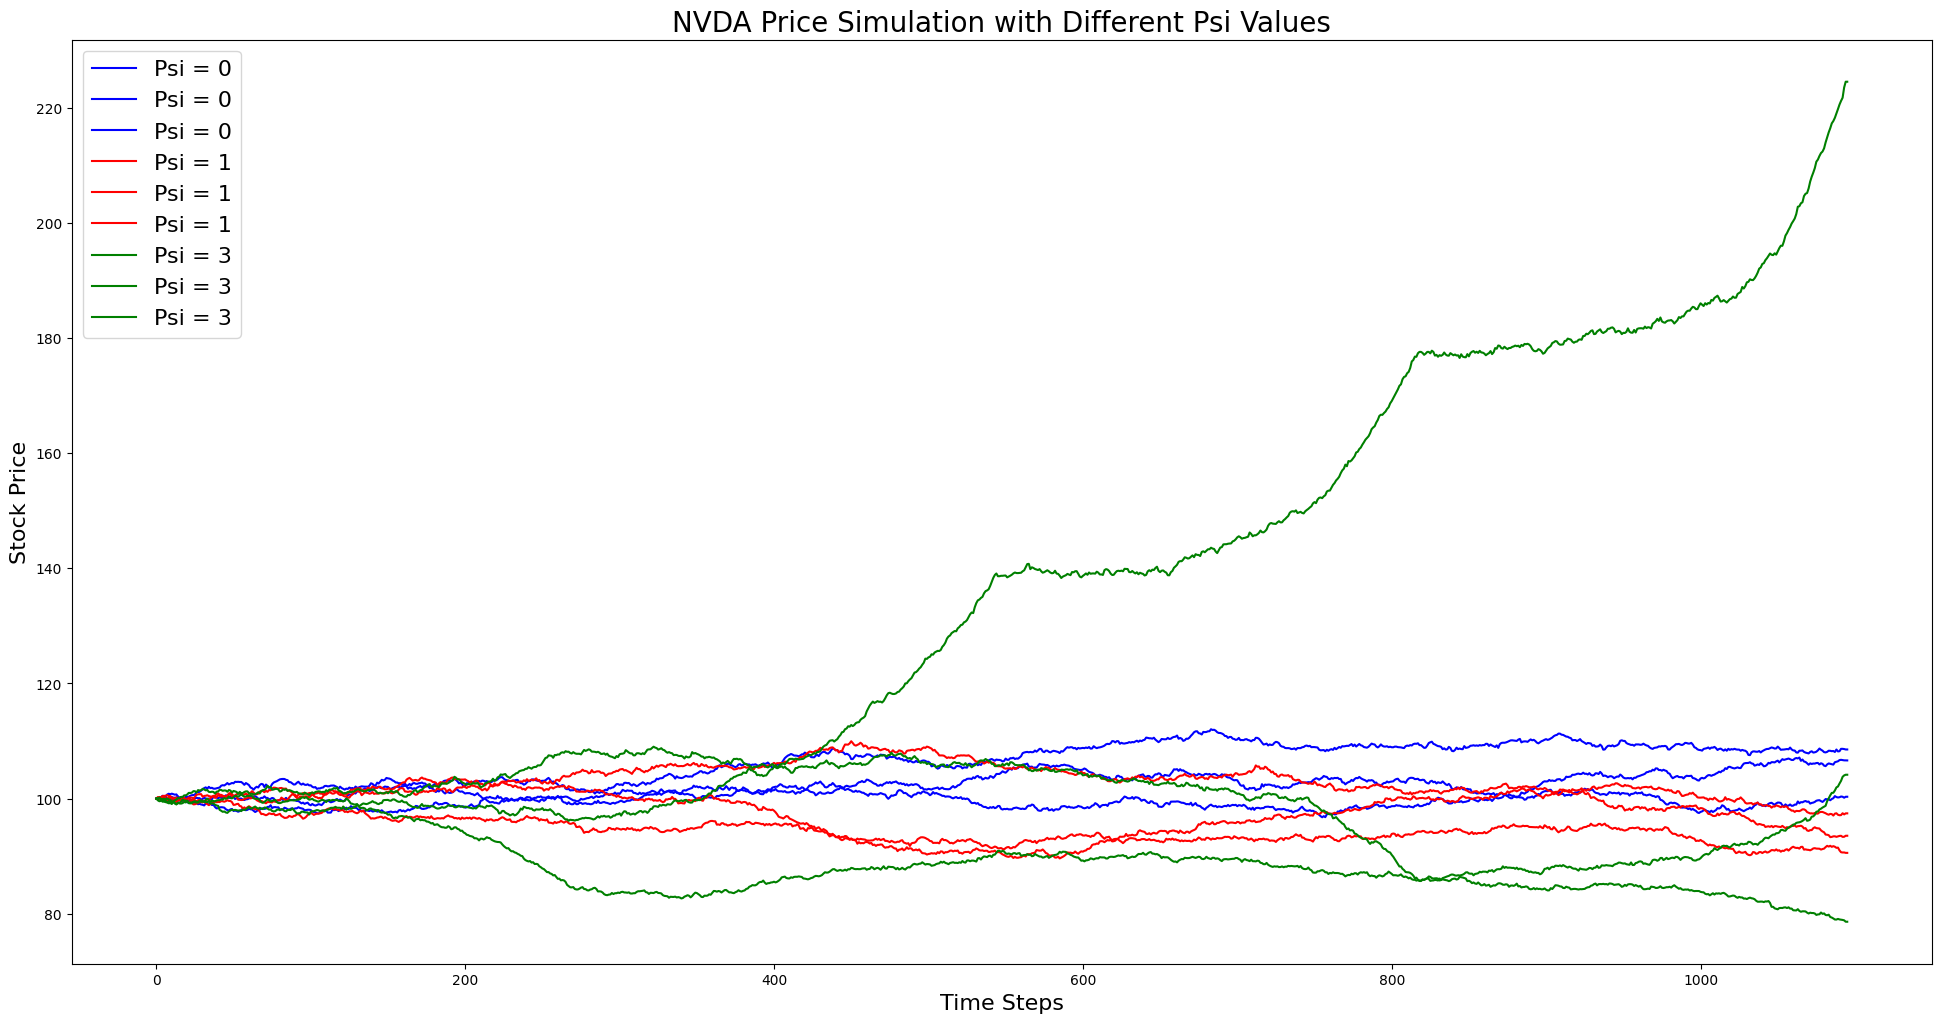

In [10]:
plt.subplots(figsize=(24,12))
plt.title('NVDA Price Simulation with Different Psi Values', fontsize=20)
plt.plot(S_NVDA_psi1.iloc[0], label='Psi = 0', color='blue')
plt.plot(S_NVDA_psi1.iloc[1], label='Psi = 0', color='blue')
plt.plot(S_NVDA_psi1.iloc[2], label='Psi = 0', color='blue')

plt.plot(S_NVDA_psi2.iloc[0], label='Psi = 1', color='red')
plt.plot(S_NVDA_psi2.iloc[1], label='Psi = 1', color='red')
plt.plot(S_NVDA_psi2.iloc[2], label='Psi = 1', color='red')

plt.plot(S_NVDA_psi3.iloc[0], label='Psi = 3', color='green')
plt.plot(S_NVDA_psi3.iloc[1], label='Psi = 3', color='green')
plt.plot(S_NVDA_psi3.iloc[2], label='Psi = 3', color='green')
plt.xlabel('Time Steps', fontsize=16)
plt.ylabel('Stock Price', fontsize=16)
plt.legend(fontsize=16) 


In [45]:
def get_quarterly_summary(results, opex_indices, quarter_len):
    stock_price = results['S']
    delta = results['delta']
    b = results['b']
    portfolio = results['portfolio']
    M_t = results['M']

    # Create a DataFrame to store the quarterly summary
    time = []
    path_count = []
    S = []
    Delta = []
    Cash = []
    Portfolio_Value = []


    for path in range(M):
        counter = 0
        for t in opex_indices:
            time.append(t)
            path_count.append(path)
            S.append(stock_price.iloc[path, t])
            Delta.append(delta.iloc[path, t])

            Cash.append(b.iloc[path, int(t / quarter_len)])
            Portfolio_Value.append(portfolio.iloc[path, counter])

            counter += 1

    df_summary = pd.DataFrame({
        'Time': time,
        'Path': path_count,
        'S': S,
        'Delta': Delta,

        'Cash': Cash,
        'Portfolio_Value': Portfolio_Value,

    })

    return df_summary


results_psi3 = simulate_full_paths(
    S0, b_0, sigma, psi=1, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
    dt=dt, N=N, M=M, opex_indices=opex_indices)


summary_df = get_quarterly_summary(results_psi3, opex_indices, quarter_len)
summary_df.pivot(index='Path', columns='Time', values=['Portfolio_Value', 'S', 'Delta', 'Cash'])

Portfolio_Value                                                      \
Time            0            273          546          819          1095   
Path                                                                       
0             3000.0  3259.717554  3075.689217  2875.540671  3011.043869   
1             3000.0  2830.192993  2912.109033  2780.186355  2428.402198   
2             3000.0  3021.249972  3075.728964  2763.507690  2458.891343   

          S                                                Delta             \
Time   0           273         546        819         1095  0          273    
Path                                                                          
0     100.0  110.324321  104.573228  98.895965  103.701462   0.0  30.818885   
1     100.0   96.006836   99.191854  95.528922   84.280073   0.0  30.821627   
2     100.0  102.375402  104.574281  95.078362   85.296378   0.0  30.820312   

                            Cash                                      
Time       546   819   1095 0          273        546    819    1095  
Path                                                                  
0     30.195973  30.0  30.0  0.0 -50.012086 -90.799615 -100.0 -100.0  
1     30.336708  30.0  30.0  0.0 -50.012086 -85.089222 -100.0 -100.0  
2     30.263413  30.0  30.0  0.0 -50.012086 -87.630191 -100.0 -100.0

In [ ]:
def expand_strikes(strike_q, opex_idx, T):
    """
    Parameters
    ----------
    strike_q : list/array of length 5
        [Q0-strike, Q1-strike, Q2-strike, Q3-strike, Q4-strike]
    opex_idx : list/array of the 5 reset indices
        e.g. [0, N/4, N/2, 3N/4, N]  (integers)
    T        : int, total number of discrete steps (N)

    Returns
    -------
    K_series : ndarray shape (T+1,)
        piece-wise-constant strike level for every time-step
    """
    K_series = np.empty(T + 1)
    for j in range(len(strike_q)):
        start = opex_idx[j]
        stop  = opex_idx[j + 1] if j + 1 < len(opex_idx) else T + 1
        K_series[start:stop] = strike_q[j]
    return K_series



In [264]:
def regional_stats(S_path, M_path, K_put_arr, K_call_arr,
                   dt, psi, *, tag=''):
    """
    K_put_arr  : lower boundary  (same length as S_path)
    K_call_arr : upper boundary
    """
    # --- cast to numpy and assert same length ---------------
    S = np.asarray(S_path)
    M = np.asarray(M_path)
    K1 = np.asarray(K_put_arr)      # lower strike  (!!!)
    K2 = np.asarray(K_call_arr)     # upper strike  (!!!)
   

    # --- classify each *step* by region ---------------------
    region = np.where(S[:-1] < K1[:-1], 'down',
             np.where(S[:-1] > K2[:-1], 'up',   'mid'))

    logret = np.diff(np.log(S))            # length T

    out = {}
    for reg in ('down', 'mid', 'up'):
        mask = region == reg
        n    = mask.sum()
        if n == 0:
            out[reg] = dict(realised_vol=0.0, mean_drift=0.0,
                            dwelling_time=0.0, hit=0)
            continue
        rv     = logret[mask].std(ddof=0) / np.sqrt(dt)
        drift  = (psi * S[:-1][mask] * M[:-1][mask]).mean()
        dwell  = n * dt
        out[reg] = dict(realised_vol=rv, mean_drift=drift,
                        dwelling_time=dwell, hit=1)

    return {f'{tag}_{k}' if tag else k: v for k, v in out.items()}


In [321]:
## Ignore this piece of code - just testing the regime statistics function.

sim_run_psi3 = simulate_full_paths(
    S0, b_0, sigma, psi=3, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
    dt=dt, N=N, M=M, opex_indices=opex_indices)

stock_price_process = np.array(sim_run_psi3['S'].iloc[0])
M_raw = np.array(results_psi3['M'].iloc[0])

strike_call, strike_put = np.array(sim_run_psi3['K_call'].iloc[0]) , np.array(results_psi3['K_put'].iloc[0])

K_put_arr  = expand_strikes(strike_put , opex_indices, N)
K_call_arr = expand_strikes(strike_call, opex_indices, N)
M_process  = np.concatenate(([0.0], M_raw))        # now length N+1


In [189]:
#  print summary statistics for each value of psi at 3 runs
reg_stats = regional_stats(stock_price_process,
                           M_process,
                           K_put_arr,            # lower strike FIRST
                           K_call_arr,           # upper strike SECOND
                           dt, psi, tag='psi3')

reg_stats

{'psi3_down': {'realised_vol': 0.0,
  'mean_drift': 0.0,
  'dwelling_time': 0.0,
  'hit': 0},
 'psi3_mid': {'realised_vol': np.float64(0.06644221030988945),
  'mean_drift': np.float64(0.1156682504507426),
  'dwelling_time': np.float64(0.884931506849315),
  'hit': 1},
 'psi3_up': {'realised_vol': np.float64(0.059996768779077315),
  'mean_drift': np.float64(28.31649028371855),
  'dwelling_time': np.float64(0.11506849315068493),
  'hit': 1}}

In [322]:
### Set-Up for Regime Statistics

S_NVDA_psi1 = NVDA_psi_0['S'] #psi = 0
S_NVDA_psi2 = NVDA_psi_1['S'] #psi = 1
S_NVDA_psi3 = NVDA_psi_3['S'] #psi = 3

M_NVDA_psi1 = NVDA_psi_0['M'] #psi = 0
M_NVDA_psi2 = NVDA_psi_1['M']  #psi = 1
M_NVDA_psi3 = NVDA_psi_3['M'] #psi = 3

strike_put_psi1 = NVDA_psi_0['K_put']
strike_put_psi2 = NVDA_psi_1['K_put']
strike_put_psi3 = NVDA_psi_3['K_put']

strike_call_psi1 = NVDA_psi_0['K_call']
strike_call_psi2 = NVDA_psi_1['K_call']
strike_call_psi3 = NVDA_psi_3['K_call']

total_runs_S = pd.concat([S_NVDA_psi1, S_NVDA_psi2, S_NVDA_psi3])
total_runs_M = pd.concat([M_NVDA_psi1, M_NVDA_psi2, M_NVDA_psi3])
total_runs_K_call = pd.concat([strike_call_psi1, strike_call_psi2, strike_call_psi3])
total_runs_K_put = pd.concat([strike_put_psi1, strike_put_psi2, strike_put_psi3])

In [247]:
K_call_df = {}
K_put_df = {}
for i in total_runs_K_call:
    K_call_df[i] = expand_strikes(total_runs_K_call.iloc[i], opex_indices, N)
    K_put_df[i] = expand_strikes(total_runs_K_put.iloc[i], opex_indices, N)
K_call_df = pd.DataFrame(K_call_df)
K_put_df = pd.DataFrame(K_put_df)

In [ ]:
rows = {}
psi_table = [0,0,0,1,1,1,3,3,3]
for run_id, S_row in total_runs_S.iterrows():          # 9 runs
    S_path = S_row.values                    # (T+1,)
    M_raw_ = total_runs_M.iloc[run_id].values
    M_path_ = np.concatenate(([0.0], M_raw_))
    stats = regional_stats(S_path, M_path_,
                           K_put_df.iloc[S_row, run_id], K_call_df.iloc[S_row, run_id],
                           dt=dt, psi=psi_table[run_id])  

    rows[run_id] = stats

psi_0_regime_stats = pd.DataFrame(rows[0])
psi_1_regime_stats = pd.DataFrame(rows[1])
psi_3_regime_stats = pd.DataFrame(rows[2])

In [316]:
psi_0_regime_stats

,down,mid,up
realised_vol,0.0,0.063787,0.071164
mean_drift,0.0,0.000000,0.000000
dwelling_time,0.0,0.122374,0.877626
hit,0.0,1.000000,1.000000


In [317]:
psi_1_regime_stats

,down,mid,up
realised_vol,0.080127,0.073397,0.0
mean_drift,0.000000,0.000000,0.0
dwelling_time,0.751598,0.248402,0.0
hit,1.000000,1.000000,0.0


In [318]:
psi_3_regime_stats

,down,mid,up
realised_vol,0.083807,0.066941,0.0
mean_drift,0.000000,0.000000,0.0
dwelling_time,0.735160,0.264840,0.0
hit,1.000000,1.000000,0.0


## SPX 


In [403]:
def simulate_full_paths_SPX(S0, b_0, sigma, psi, zeta, phi, theta_0, b,
                        dt, N, M, opex_indices, asset_type='SPX'):

    '''
    N : number of simulations
    M : number of time steps
    theta_0 : Number of Puts and Calls bought (option size)
    '''
    #Stock Price
    S = np.zeros((M, N + 1))
    S[:, 0] = S0
    dDelta = np.zeros((M, N))
    M_t = np.zeros((M, N))
    delta_t = np.zeros((M, N + 1))


    #Greeks
    charm = np.zeros((M, N))
    speed = np.zeros((M, N))
    gamma_greek = np.zeros((M, N))

    #MMA



    #Number of Options

    K_call = np.zeros((M, len(opex_indices)))
    K_put = np.zeros((M, len(opex_indices)))
    b_t_I = np.zeros((M, len(opex_indices)+1))
    b_t_I[:, 0] = b_0
    portfolio_value = np.zeros((M, N))
    portfolio_value[:, 0] = abs(b)
    exp_phi_dt = np.exp(-phi * dt)  # Precompute exp(-phi * dt) for efficiency

    #Opex Date Logic
    T_remain = 0.25
    sqrt_remain = np.sqrt(T_remain)
    sqrt_dt = np.sqrt(dt)

    for path in range(M):
        for t in range(N + 1):
            if t == 0:
                #Opex idx counter
                idx = 0
                S_t = S0
                #Strike Price
                K_call[path, 0] = S0 * np.exp(sigma * sqrt_remain)
                K_put[path, 0] = S0 * np.exp(-sigma * sqrt_remain)

                #Black Sholes Price
                put_price = bs_put_price(S=S0, K=K_put[path, 0], T=T_remain, sigma=sigma)
                call_price = bs_call_price(S=S0, K=K_call[path, 0], T=T_remain, sigma=sigma)

                #Stock Process
                delta_call = bs_delta(S0, K_call[path, 0], T_remain, sigma, 'call')
                delta_put = bs_delta(S0, K_put[path, 0], T_remain, sigma, 'put')

                theta_t = theta_0

                b_t_I[path, 1] = b_0 - theta_0*(put_price - call_price)
                dDelta[path,0]= (delta_put - delta_call)*theta_0

                prev_delta = theta_0 * (1+delta_put - delta_call)
                portfolio_value [path, 0] = S0*theta_0

            if t > 0 and t not in opex_indices:
                delta_t[path, t] = prev_delta
                M_prev = M_t[path, t-2] if t > 1 else 0.0
                last_opex_t = max([i for i in opex_indices if i < t])
                tau = T_remain - (t - last_opex_t) * dt
                tau = max(tau, 1e-6)
                # Calculate the feedback and diffusion terms

                # 1. Calculate dDelta
                Call_Gamma, Call_Charm, Call_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_call[path, idx],
                                         T = tau)
                # For Put
                Put_Gamma, Put_Charm, Put_Speed = dDeltaCalc(
                                         S_t = S_t,
                                         sigma = sigma,
                                         K = K_put[path, idx],
                                         T = tau)
                # Calculate net Greeks
                net_gamma =  (Call_Gamma + Put_Gamma)
                net_charm =  (Call_Charm + Put_Charm)
                net_speed =  (Call_Speed + Put_Speed)
                charm[path, t-1] = net_charm
                gamma_greek[path, t-1] = net_gamma
                speed[path, t-1] = net_speed
                #Calculate dDelta_dealer

                dW = np.random.normal(0, sqrt_dt)
                dt_terms = net_charm + (net_gamma * M_prev * S_t * psi) + 0.5*(net_speed*sigma**2 *S_t**(2-2*zeta))
                dW_terms = dW * sigma * S_t**(1-zeta) * net_gamma
                dDelta_Current = dt_terms*dt + dW_terms

                dDelta[path, t-1] = dDelta_Current

                # 2. Calculate M_t
                M_t[path, t-1] = exp_phi_dt * M_prev + dDelta_Current

                # 3. Calculate Diffusion
                diffusion = sigma * S_t **(1 - zeta) * dW
                # 4. Calculate Drift
                drift = psi * S_t * M_prev * dt
                # 4. Update New S_t

                S[path, t] =  diffusion + drift + S_t
                S_t = S[path, t]



            if t in opex_indices and t != 0:
                #Initial Opex Logic
                M_t[path, t-1] = 0
                idx = opex_indices.index(t)

                #New Option's Strike Price for the upcoming Period
                K_call[path, idx] = S_t * np.exp(sigma * sqrt_remain) + 0.25 * (diffusion / dW)
                K_put[path, idx] = S_t * np.exp(-sigma * sqrt_remain) - 0.25 * (diffusion / dW)
                #New Options Prices
                call_price = bs_call_price(S=S_t, K=K_call[path, idx], T=T_remain, sigma=sigma)
                put_price = bs_put_price(S=S_t, K=K_put[path, idx], T=T_remain, sigma=sigma)



                #Calculate Payoff from Matured Option
                call_payoff = theta_t * max(S_t - K_call[path, idx - 1], 0)
                put_payoff = theta_t * max(K_put[path, idx - 1] - S_t, 0)


                #Update Money in MMA
                b_t = b_t_I[path, idx] + (-call_payoff + put_payoff) * theta_t


                #If we are within our borrowing limits
                avaliable_money = b_t - b
                if avaliable_money >= theta_0 * (put_price + call_price):
                    theta_new = theta_0
                else:
                    theta_new = (b_t - b + theta_0*call_price) / put_price

                #New Money in MMA
                b_t_I[path, idx+1] = b_t - theta_new * put_price + theta_0*call_price
                #New Delta Calculations
                delta_call_new = bs_delta(S_t, K_call[path, idx], T_remain, sigma, 'call')
                delta_put_new = bs_delta(S_t, K_put[path, idx], T_remain, sigma, 'put')
                #Delta Jump [‼️i add 1 because we need to include the delta for the underlying]
                new_delta = theta_0*1 + theta_new * (delta_put_new - delta_call_new)
                dDelta[path, t - 1] = new_delta - prev_delta
                #Update Deltas
                delta_t[path, t] = new_delta
                prev_delta = new_delta
                #Portfolio value
                portfolio_value[path, idx] = - theta_new * put_price + theta_0*call_price + b_t_I[path, idx+1] + theta_0*S_t
                theta_t = theta_new
                S[path, t] = S_t







    return {
        'S': pd.DataFrame(S),
        'b': pd.DataFrame(b_t_I),
        'M': pd.DataFrame(M_t),
        'dDelta': pd.DataFrame(dDelta),
        'delta': pd.DataFrame(delta_t),
        'gamma': pd.DataFrame(gamma_greek),
        'speed': pd.DataFrame(speed),
        'charm' : pd.DataFrame(charm),
        'portfolio': pd.DataFrame(portfolio_value),
        'K_put': pd.DataFrame(K_put),
        'K_call': pd.DataFrame(K_call)
    }

In [326]:
SPX_psi_0 = simulate_full_paths(
    S0, b_0, sigma, 0, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

SPX_psi_1 = simulate_full_paths(
    S0, b_0, sigma, 1, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

SPX_psi_3 = simulate_full_paths(
    S0, b_0, sigma, 3, zeta, phi, theta_0, b, dt, N, M, opex_indices, asset_type='SPX')

# Extract the data from the simulation
S_SPX_psi1 = SPX_psi_0['S']
S_SPX_psi2 = SPX_psi_1['S']
S_SPX_psi3 = SPX_psi_3['S']


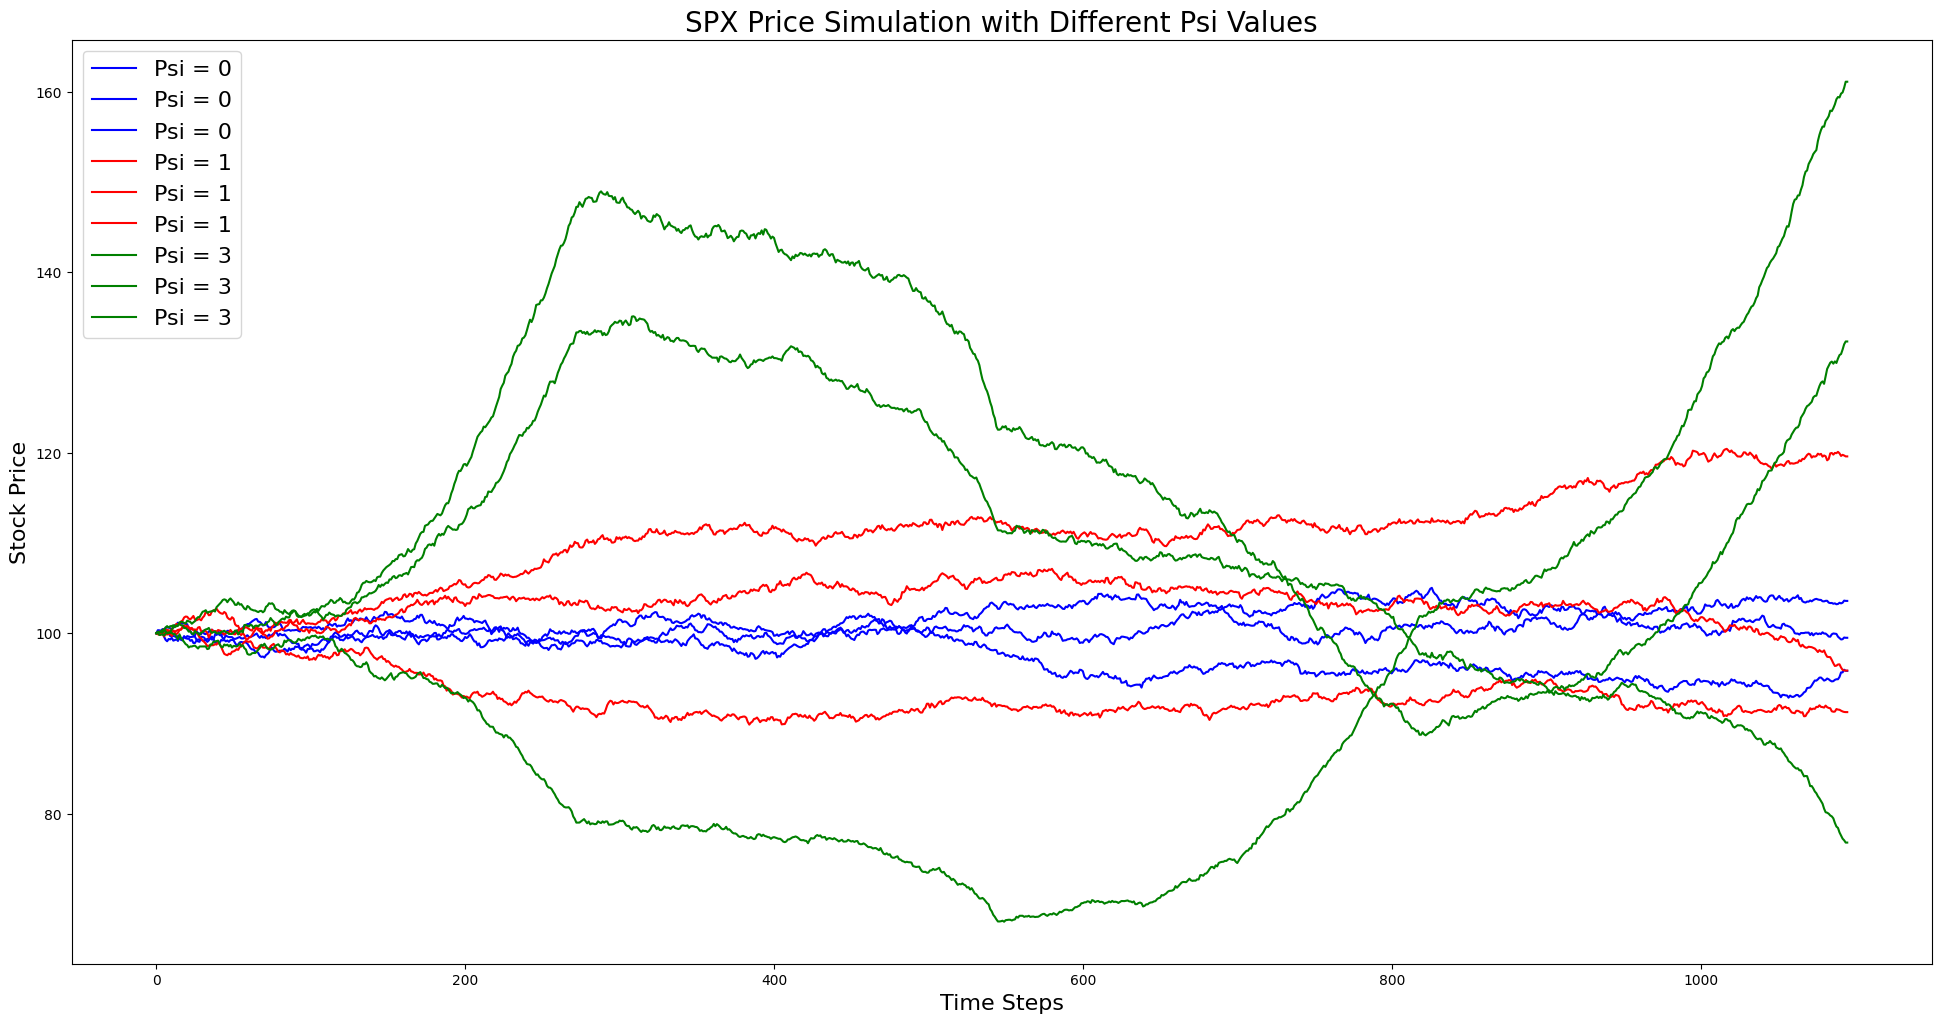

In [328]:
plt.subplots(figsize=(24,12))
plt.title('SPX Price Simulation with Different Psi Values', fontsize=20)
plt.plot(S_SPX_psi1.iloc[0], label='Psi = 0', color='blue')
plt.plot(S_SPX_psi1.iloc[1], label='Psi = 0', color='blue')
plt.plot(S_SPX_psi1.iloc[2], label='Psi = 0', color='blue')

plt.plot(S_SPX_psi2.iloc[0], label='Psi = 1', color='red')
plt.plot(S_SPX_psi2.iloc[1], label='Psi = 1', color='red')
plt.plot(S_SPX_psi2.iloc[2], label='Psi = 1', color='red')

plt.plot(S_SPX_psi3.iloc[0], label='Psi = 3', color='green')
plt.plot(S_SPX_psi3.iloc[1], label='Psi = 3', color='green')
plt.plot(S_SPX_psi3.iloc[2], label='Psi = 3', color='green')
plt.xlabel('Time Steps', fontsize=16)
plt.ylabel('Stock Price', fontsize=16)
plt.legend(fontsize=16)


In [404]:
A = [0, 1, 3] 
summary_df_concat = {}
for psi in range(len(A)+1):

    if psi == 2:
        pass
    else:
        results_psi = simulate_full_paths_SPX(
            S0, b_0, sigma, psi=psi, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
            dt=dt, N=N, M=M, opex_indices=opex_indices
        )
        summary_df = get_quarterly_summary(results_psi, opex_indices, quarter_len)
        summary_df_concat[psi] =  summary_df
        # Print dynamic title based on the current psi value
        print(f"Quarterly Summary for ψ = {psi}")


Quarterly Summary for ψ = 0
Quarterly Summary for ψ = 1
Quarterly Summary for ψ = 3


In [413]:
psi_spx_0 = summary_df_concat[0]
psi_spx_1 = summary_df_concat[1]
psi_spx_3 = summary_df_concat[3]

In [417]:
psi_spx_0

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,101.690883,22.564739,2.498523,3060.099951
2,546,0,102.913815,22.558943,5.935997,3100.304142
3,819,0,102.788974,22.562769,9.412841,3100.029900
4,1095,0,104.243161,22.556239,12.886767,3147.223237
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,98.514287,22.579303,2.498523,2964.596784
7,546,1,95.108551,22.597770,5.833342,2865.540444
8,819,1,92.265773,22.615597,9.058627,2783.300318
9,1095,1,91.944605,22.613744,12.192871,2776.776585


In [418]:
psi_spx_1

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000,3000.000000
1,273,0,104.438762,22.558670,2.498523,3142.717929
2,546,0,99.894176,22.578537,6.026791,3009.614618
3,819,0,124.323232,3944.855123,9.408070,14628.056905
4,1095,0,133.124211,20.966233,-100.000000,3893.726328
5,0,1,100.000000,0.000000,0.000000,3000.000000
6,273,1,94.481100,22.603904,2.498523,2843.343323
7,546,1,84.688709,22.660317,5.704422,2552.143844
8,819,1,81.068713,22.681113,8.593504,2446.196859
9,1095,1,80.388353,22.681819,11.364484,2428.510875


In [416]:
psi_spx_3

,Time,Path,S,Delta,Cash,Portfolio_Value
0,0,0,100.000000,0.000000,0.000000e+00,3.000000e+03
1,273,0,126.547855,5037.639687,2.498523e+00,1.802162e+04
2,546,0,97.594113,22.595107,-1.000000e+02,5.968872e+09
3,819,0,97.856102,22.589049,5.968869e+09,5.968872e+09
4,1095,0,128.259097,22.451390,5.968869e+09,5.968856e+09
5,0,1,100.000000,0.000000,0.000000e+00,3.000000e+03
6,273,1,64.479078,22.795613,2.498523e+00,2.534552e+04
7,546,1,47.315669,22.977541,2.340892e+04,3.373374e+04
8,819,1,28.284297,23.274003,3.231261e+04,4.542324e+04
9,1095,1,19.728735,23.495141,4.457370e+04,4.989170e+04


In [419]:
SPX_spi_0 = simulate_full_paths_SPX(
            S0, b_0, sigma, psi=0, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
            dt=dt, N=N, M=M, opex_indices=opex_indices
        )#psi = 0

SPX_spi_1 = simulate_full_paths_SPX(
            S0, b_0, sigma, psi=1, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
            dt=dt, N=N, M=M, opex_indices=opex_indices
        ) #psi = 1

SPX_spi_3 = simulate_full_paths_SPX(
            S0, b_0, sigma, psi=3, zeta=zeta, phi=phi, theta_0=theta_0, b=b,
            dt=dt, N=N, M=M, opex_indices=opex_indices
        ) #psi = 3

In [497]:
### Set-Up for Regime Statistics

S_SPX_psi1 = SPX_spi_0['S']
S_SPX_psi2 = SPX_spi_1['S'] #psi = 1
S_SPX_psi3 = SPX_spi_3['S'] #psi = 3

M_SPX_psi1 = SPX_spi_0['M'] #psi = 0
M_SPX_psi2 = SPX_spi_1['M']  #psi = 1
M_SPX_psi3 = SPX_spi_3['M'] #psi = 3

strike_put_SPX1 = SPX_spi_0['K_put']
strike_put_SPX2 = SPX_spi_1['K_put']
strike_put_SPX3 = SPX_spi_3['K_put']

strike_call_SPX1 = SPX_spi_0['K_call']
strike_call_SPX2 = SPX_spi_1['K_call']
strike_call_SPX3 = SPX_spi_3['K_call']

total_runs_S_SPX = pd.concat([S_SPX_psi1, S_SPX_psi2, S_SPX_psi3])
total_runs_M_SPX = pd.concat([M_SPX_psi1, M_SPX_psi2, M_SPX_psi3])
total_runs_K_call_SPX = pd.concat([strike_call_SPX1, strike_call_SPX2, strike_call_SPX3])
total_runs_K_put_SPX = pd.concat([strike_put_SPX1, strike_put_SPX2, strike_put_SPX3])

In [508]:
K_call_df_SPX = {}
K_put_df_SPX = {}
for i in total_runs_K_call_SPX:
    K_call_df_SPX[i] = expand_strikes(total_runs_K_call_SPX.iloc[i], opex_indices, N)
    K_put_df_SPX[i] = expand_strikes(total_runs_K_put_SPX.iloc[i], opex_indices, N)
K_call_df_SPX = pd.DataFrame(K_call_df_SPX)
K_put_df_SPX = pd.DataFrame(K_put_df_SPX)

rows_SPX = {}
psi_table_SPX = [0,0,0,1,1,1,3,3,3]
for run_id, S_row in total_runs_S_SPX.iterrows():          # 9 runs
    S_path = S_row.values                    # (T+1,)
    M_raw_ = total_runs_M.iloc[run_id].values
    M_path_ = np.concatenate(([0.0], M_raw_))
    stats = regional_stats(S_path, M_path_,
                           K_put_df_SPX.iloc[S_row, run_id], K_put_df_SPX.iloc[S_row, run_id],
                           dt=dt, psi=psi_table[run_id])  

    rows_SPX[run_id] = stats

SPX_psi_0_regime_stats = pd.DataFrame(rows_SPX[0])
SPX_psi_1_regime_stats = pd.DataFrame(rows_SPX[1])
SPX_psi_3_regime_stats = pd.DataFrame(rows_SPX[2])

In [509]:
SPX_psi_0_regime_stats

,down,mid,up
realised_vol,0.0,0.0,0.073866
mean_drift,0.0,0.0,0.000000
dwelling_time,0.0,0.0,1.000000
hit,0.0,0.0,1.000000


In [510]:
SPX_psi_1_regime_stats

,down,mid,up
realised_vol,0.0,0.0,0.06825
mean_drift,0.0,0.0,0.00000
dwelling_time,0.0,0.0,1.00000
hit,0.0,0.0,1.00000


In [511]:
SPX_psi_3_regime_stats

,down,mid,up
realised_vol,0.074096,0.0,0.068278
mean_drift,0.000000,0.0,0.000000
dwelling_time,0.536073,0.0,0.463927
hit,1.000000,0.0,1.000000


### Question 12

Given the stock price dynamics are order flow driven, we can benefit from the predictablility of the underlying price and take positions depending on what regime/dynamics are, and what the market makers must do to remain hedged.

If the stock is trading below the put strike, we know when the market maker is short gamma, they will need to sell the underlying in order to remain delta-hedged. This will exert further downward pressure on the stock. From Question 11, we know this exhibits a period of high volatility within a short-period of time. An ideal trade in this scenario would be to take a bearish position either via buying puts or out right shorting the underlying (where this depends on the impact our AUM has on the market and the overall hedging-dependent drift)

If the stock is trading between the strikes, and the market maker is relatively flat on gamma, the market as observed is likely to be stickier, which could allow us to benefit from call overwriting strategies and/or selling protective puts (depending on if we have a directional view)

Finally, if the stock is trading beyond the higher call-strike and the market maker is long-gamma, this tends to result in the typical pinning/gamma-squeeze. This is almost opposite to the first scenario when the market maker is short-gamma and the underlying is below the first strike. Now the market maker will most likely buy the underlying to remain delta-flat, which further contributes to the upwards momentum. This again is typically the most exaggerated towards the strike expiry date and also has a typically short mean dwelling time. Here, our AUM can impact the market driving upwards the price, contributing to even more buying pressure and increasing the likelihood of our strategy being successful.

Mean dwelling time 

In [514]:
w = 1000000 #AUM 
CFG = dict(
    max_delta_frac = 0.05,      # |Δ| limit as fraction of NAV
    max_vega_frac  = 0.02,      # |vega| limit
    hprime_steps   = 24,        # trade only every h' steps (e.g. 4h if dt=10 min)
    cheap_IV_mult  = 0.90,      # IV < 0.9×realised ⇒ vol is cheap
    rich_IV_mult   = 1.10       # IV > 1.1×realised ⇒ vol is rich
)


In [513]:
# ───────────────────────────── position rules from play-book ─────────────────
def position_rules(zone, IV, RV, w, S,
                   max_delta, max_vega):
    """determine (delta_target, vega_target) given current zone & vols"""
    if zone == 'up' and IV < CFG['cheap_IV_mult']*RV:
        # ride squeeze
        delta =  0.05*w/S
        vega  =  0.0
    elif zone == 'up':
        # gamma-scalp (short call, reduced long Δ)
        delta =  0.02*w/S
        vega  = -0.02*w
    elif zone == 'mid' and IV < CFG['cheap_IV_mult']*RV:
        # long cheap vol
        delta = 0.0
        vega  = 0.02*w
    elif zone == 'down' and IV < CFG['cheap_IV_mult']*RV:
        # buy protection / ride air-pocket
        delta = -0.03*w/S
        vega  =  0.03*w
    elif zone == 'down':
        # sell expensive puts
        delta = -0.01*w/S
        vega  = -0.02*w
    else:
        delta = vega = 0.0

    # enforce limits
    delta = np.clip(delta, -max_delta, max_delta)
    vega  = np.clip(vega,  -max_vega,  max_vega)
    return delta, vega

In [515]:
# ───────────────────────────────── helper: region label ──────────────────────
def classify_zone(S, K_put, K_call):
    """return 'down' / 'mid' / 'up' for each step (array len T)"""
    return np.where(S < K_put, 'down',
           np.where(S > K_call, 'up',  'mid'))


In [516]:
# ───────────────────────── main back-test routine ────────────────────────────
def run_fbi_strategy(S_path,    # ndarray (T+1,)
                     K_put_arr, # lower strike array (T+1,)
                     K_call_arr,# upper strike array (T+1,)
                     IV_path,   # implied vol per step (T+1,) or scalar
                     dt,
                     w0=1_000_000,
                     r=0.0):
    T = len(S_path) - 1
    zone = classify_zone(S_path[:-1], K_put_arr[:-1], K_call_arr[:-1])

    # pre-allocate book-keeping arrays
    nav   = np.full(T+1, w0, dtype=float)
    delta = np.zeros(T+1)       # our underlying position size
    vega  = np.zeros(T+1)       # not priced → track exposure only
    trade_delta = np.zeros(T+1)

    # realised vol running estimator (EWMA for demo)
    rv = np.zeros(T+1); rv[0] = IV_path[0] if np.ndim(IV_path)>0 else IV_path
    alpha = 0.01                # EWMA decay

    max_delta = CFG['max_delta_frac']*w0/S_path[0]
    max_vega  = CFG['max_vega_frac'] *w0

    for t in range(T):
        # update realised vol estimator
        rv[t] = (1-alpha)*rv[t-1] + alpha*abs(np.log(S_path[t+1]/S_path[t]))/np.sqrt(dt)

        # trade every h' steps OR if zone changes
        if (t % CFG['hprime_steps'] == 0) or (zone[t] != zone[t-1] if t else True):
            IV = IV_path[t] if np.ndim(IV_path)>0 else IV_path
            d_target, v_target = position_rules(zone[t], IV, rv[t],
                                                nav[t], S_path[t],
                                                max_delta, max_vega)
            # adjust delta position
            trade_delta[t] = d_target - delta[t]
            delta[t+1] = d_target
            vega [t+1] = v_target
        else:
            # carry positions forward
            delta[t+1] = delta[t]
            vega [t+1] = vega [t]

        # P&L from delta position over (t,t+1]
        nav[t+1] = nav[t] + delta[t]*(S_path[t+1]-S_path[t]) + nav[t]*r*dt

    return pd.DataFrame({
        'S'     : S_path,
        'zone'  : np.append(zone, zone[-1]),
        'NAV'   : nav,
        'delta' : delta,
        'vega'  : vega,
        'tradeΔ': trade_delta
    })

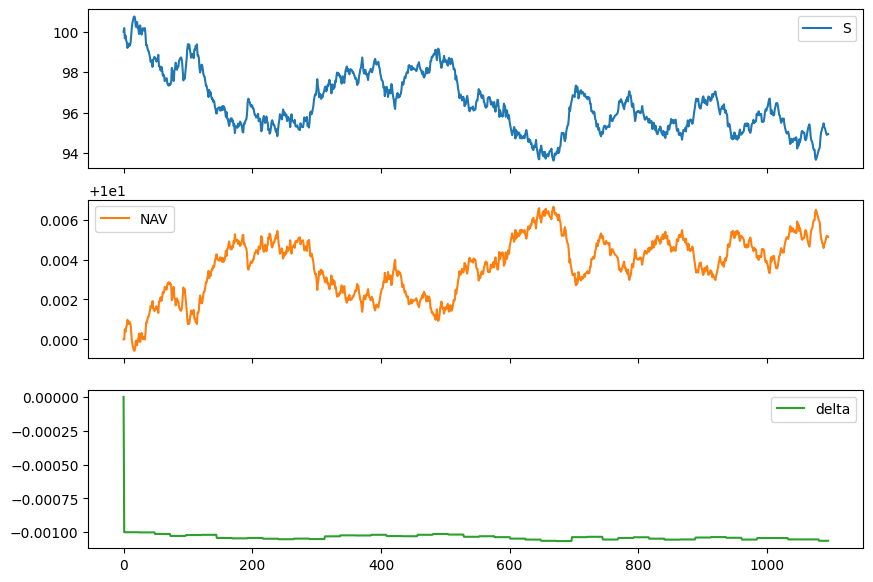

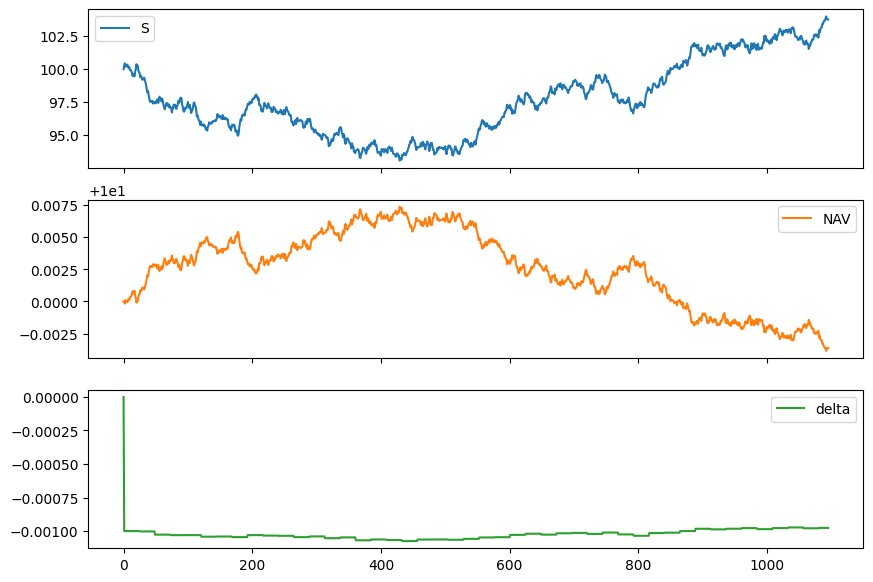

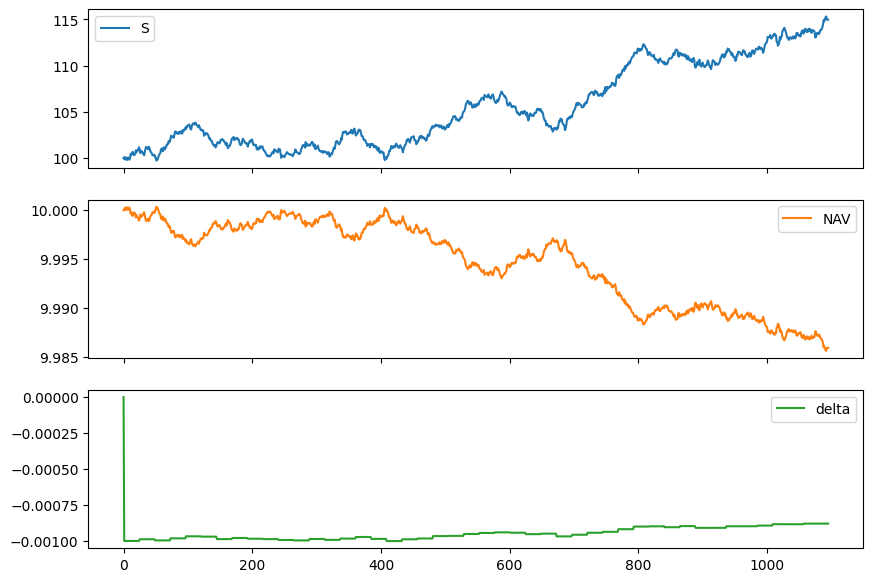

In [520]:
#SPX, psi = 0

for i in range(len(S_SPX_psi1)):
    result_SPX_psi1 = run_fbi_strategy(
                S_path      = S_SPX_psi1.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_call_SPX1.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_put_SPX1.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_SPX_psi1[['S','NAV','delta']].plot(subplots=True, figsize=(10,7))


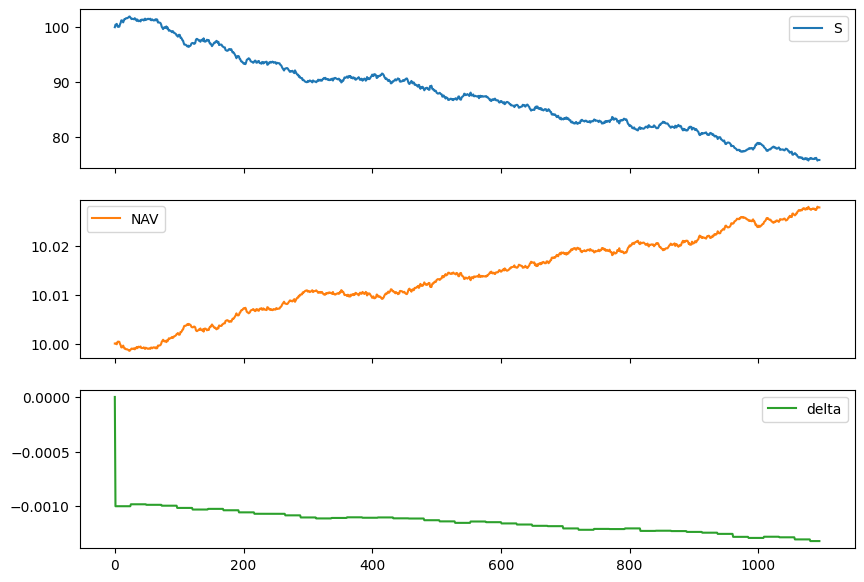

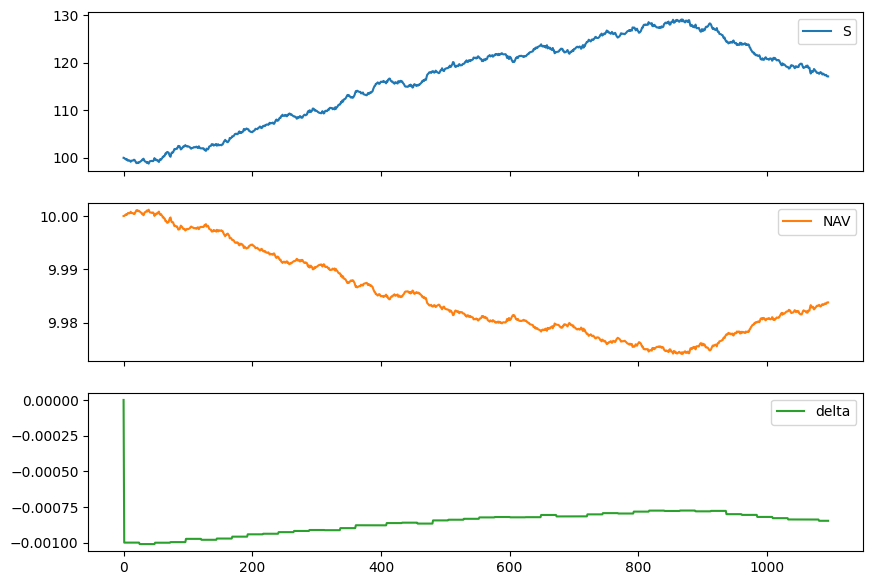

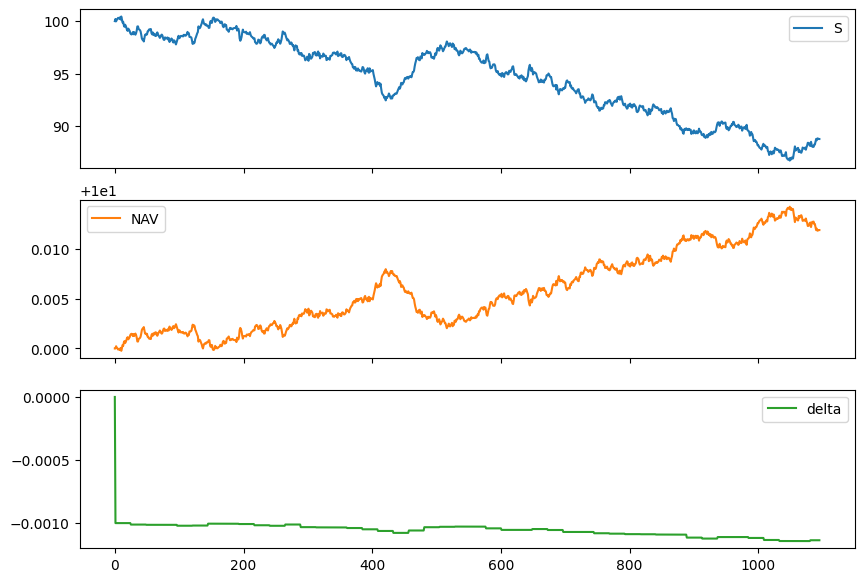

In [521]:
#SPX, psi = 1

for i in range(len(S_SPX_psi1)):
    result_SPX_psi2 = run_fbi_strategy(
                S_path      = S_SPX_psi2.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_call_SPX2.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_put_SPX2.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_SPX_psi2[['S','NAV','delta']].plot(subplots=True, figsize=(10,7))


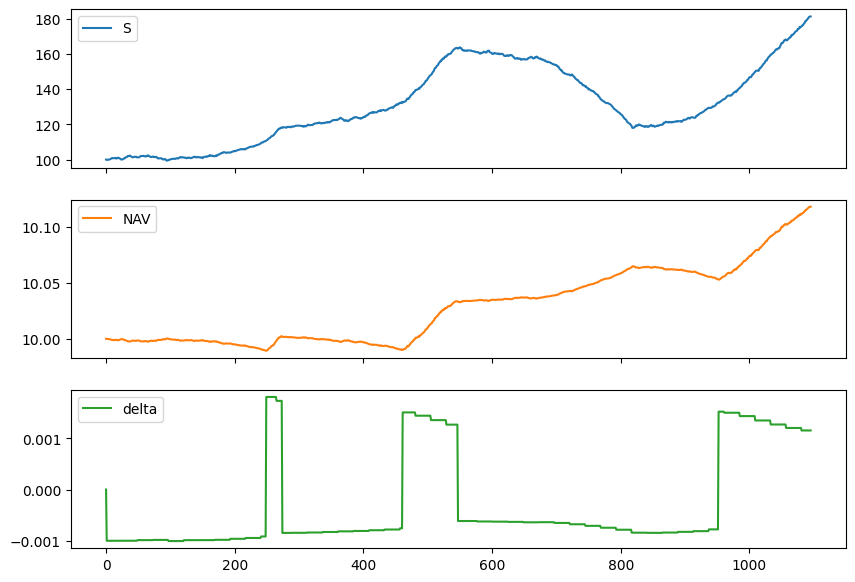

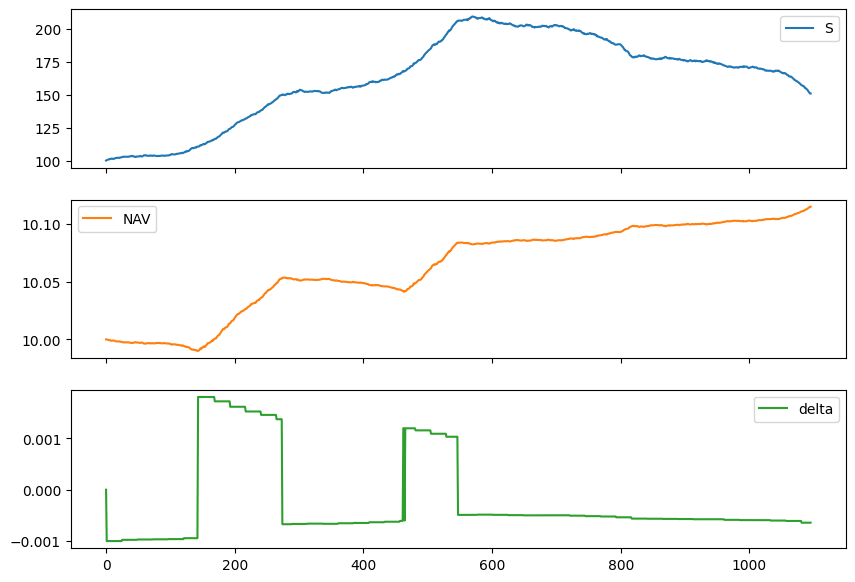

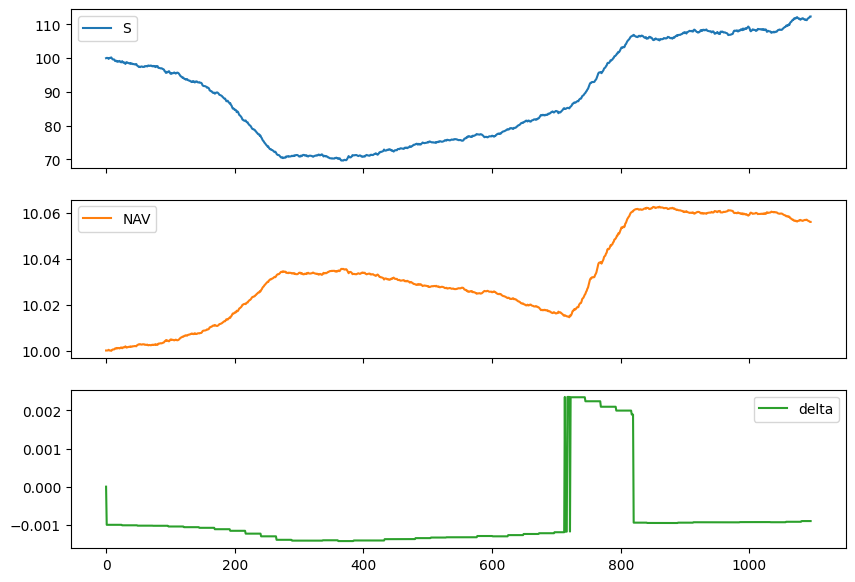

In [523]:
#SPX, psi = 3

for i in range(len(S_SPX_psi1)):
    result_SPX_psi3 = run_fbi_strategy(
                S_path      = S_SPX_psi3.iloc[i],   # ndarray T+1
                K_put_arr   = expand_strikes(strike_call_SPX3.iloc[i], opex_indices, N),
                K_call_arr  = expand_strikes(strike_put_SPX3.iloc[i], opex_indices, N),
                IV_path     = sigma,    # or scalar σ_IV
                dt          = dt,
                w0          = w0
)
    result_SPX_psi3[['S','NAV','delta']].plot(subplots=True, figsize=(10,7))


When estimating these statistics, use different sampling frequencies, especially those lower (less frequent) than the dt = h you have chosen that sets the step size (why?)

Rebalancing at larger time steps means less frequent rebalancing. This results in us locking in our profits at bigger intervals which effectively means we 'make less bets'. We can miss out on more profit-taking and/or loss making opportunities. In a higher volatility environment where mean dwelling time in a favourable zone is short, we can potentially miss out on higher gains. In the middle volatility environment, where for example call overwriting strategies is used, this longer timeframe to sell calls can also result in us having to buy/sell less to achieve the same returns can mean we pay less transaction fees. 